In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/home/huyho/earth_predict_env/Dataset/NF-ToN-IoT-v3.csv"
raw_data = pd.read_csv(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


: 

In [ ]:
summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Unique Values': df.nunique().values,
    'Sample Value': [df[col].iloc[0] for col in df.columns]
})
summary

,Column,Data Type,Missing Values,Unique Values,Sample Value
0,FLOW_START_MILLISECONDS,int64,0,1893404,1424242193040
1,FLOW_END_MILLISECONDS,int64,0,2299732,1424242193043
2,IPV4_SRC_ADDR,object,0,40,59.166.0.2
3,L4_SRC_PORT,int64,0,64597,4894
4,IPV4_DST_ADDR,object,0,40,149.171.126.3
5,L4_DST_PORT,int64,0,64617,53
6,PROTOCOL,int64,0,255,17
7,L7_PROTO,float64,0,141,5.0
8,IN_BYTES,int64,0,13658,146
9,IN_PKTS,int64,0,892,2


Attack
Benign            2237731
Exploits            42748
Fuzzers             33816
Generic             19651
Reconnaissance      17074
DoS                  5980
Backdoor             4659
Shellcode            2381
Analysis             1226
Worms                 158
Name: count, dtype: int64

% distribution:
Attack
Benign            94.60
Exploits           1.81
Fuzzers            1.43
Generic            0.83
Reconnaissance     0.72
DoS                0.25
Backdoor           0.20
Shellcode          0.10
Analysis           0.05
Worms              0.01
Name: count, dtype: float64


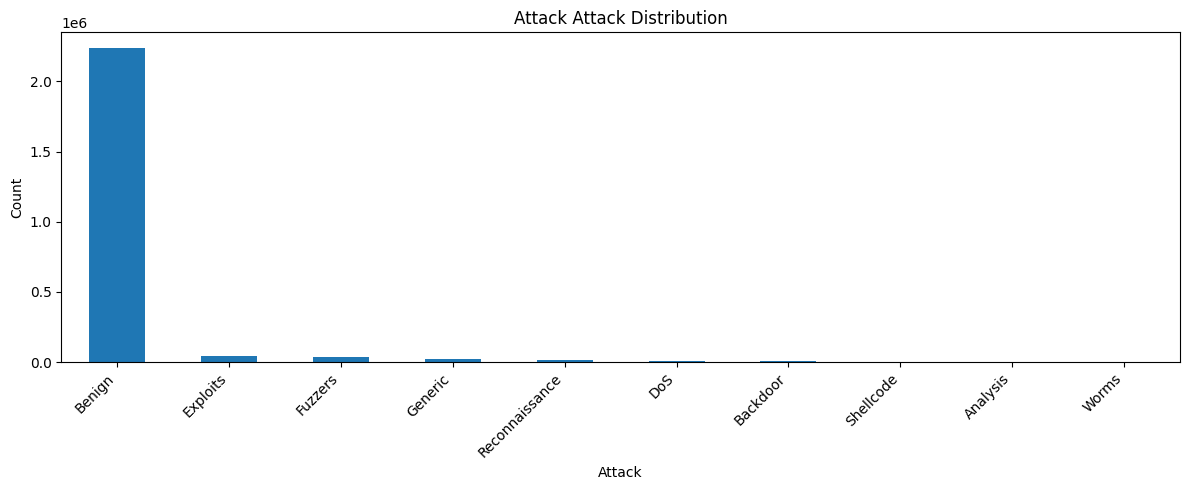

In [ ]:
# ── Attack distribution ──────────────────────────────────────────────────────
label_counts = df['Attack'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Attack Distribution')
plt.xlabel('Attack'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


In [4]:

# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'Benign': 'BENIGN',
    'DDoS': 'DDoS',
    'DoS': 'DoS',
    'Brute Force': 'Brute Force',
    'Infilteration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  400,000  (32.25%)
  DDoS                    300,000  (24.19%)
  DoS                     299,999  (24.19%)
  Brute Force             123,982  (10.00%)
  Infiltration            116,361  (9.38%)


In [5]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Dataset    1240342
dtype: int64

INFINITY VALUES
{'SRC_TO_DST_SECOND_BYTES': np.int64(3)}


In [6]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


NaN remaining : 1240342
Shape         : (1240342, 43)


/tmp/ipykernel_264599/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/home/huyho/.local/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/tmp/ipykernel_264599/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pand

In [7]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : []
Shape   : (1240342, 43)


In [8]:
# ── Remove low-variance features ─────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

y = df_processed['Label']
X = df_processed.drop('Label', axis=1)

selector = VarianceThreshold(threshold=0.01)
X_hv = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

df_processed = pd.DataFrame(X_hv, columns=selected_features)
df_processed['Label'] = y.values

print(f"Features : {X.shape[1]} → {len(selected_features)} (removed {X.shape[1]-len(selected_features)})")
print(f"Shape    : {df_processed.shape}")


Features : 42 → 41 (removed 1)
Shape    : (1240342, 42)


/home/huyho/.local/lib/python3.10/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)


In [9]:
# ── Remove outliers via Z-score (threshold = 3) ──────────────────────────────
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import pickle

X_temp = df_processed.drop('Label', axis=1)
y_temp = df_processed['Label']

mask = (np.abs(stats.zscore(X_temp)) < 3).all(axis=1)
df_processed = X_temp[mask].copy()
df_processed['Label'] = y_temp[mask]

print(f"Removed  : {(~mask).sum()} outliers ({(~mask).mean()*100:.2f}%)")



Removed  : 264230 outliers (21.30%)


In [10]:
# ── Drop highly correlated features (r > 0.95) ───────────────────────────────
X_for_corr = df_processed.drop('Label', axis=1)
upper = X_for_corr.corr().abs().where(
    np.triu(np.ones(X_for_corr.shape[1], dtype=bool), k=1))
to_drop = [c for c in upper.columns if upper[c].max() > 0.95]

df_processed.drop(columns=to_drop, inplace=True)
print(f"Dropped  : {len(to_drop)} correlated features")

Dropped  : 4 correlated features


In [11]:
# ── Label encoding ───────────────────────────────────────────────────────────
le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

with open('label_encoder.pkl1', 'wb') as f:
    pickle.dump(le, f)

print(f"\nShape    : {df_processed.shape}")
for idx, label in enumerate(le.classes_):
    print(f"  {idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum():,} samples)")


Shape    : (976112, 39)
  0: BENIGN  (220,715 samples)
  1: Brute Force  (106,797 samples)
  2: DDoS  (280,359 samples)
  3: DoS  (294,052 samples)
  4: Infiltration  (74,189 samples)


In [12]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (780889, 37)  |  Test : (195223, 37)


In [13]:
# ── Final feature summary ─────────────────────────────────────────────────────
print(f"Features : {X_train.shape[1]}  |  Classes : {len(le.classes_)}")
print(f"Train    : {X_train.shape[0]:,} samples")
print(f"Test     : {X_test.shape[0]:,} samples")
for i, c in enumerate(X_train.columns, 1):
    print(f"  {i:3d}. {c}")


Features : 37  |  Classes : 5
Train    : 780,889 samples
Test     : 195,223 samples
    1. L4_SRC_PORT
    2. L4_DST_PORT
    3. PROTOCOL
    4. L7_PROTO
    5. IN_BYTES
    6. IN_PKTS
    7. OUT_BYTES
    8. OUT_PKTS
    9. TCP_FLAGS
   10. CLIENT_TCP_FLAGS
   11. SERVER_TCP_FLAGS
   12. FLOW_DURATION_MILLISECONDS
   13. DURATION_IN
   14. DURATION_OUT
   15. MIN_TTL
   16. LONGEST_FLOW_PKT
   17. SHORTEST_FLOW_PKT
   18. MIN_IP_PKT_LEN
   19. SRC_TO_DST_SECOND_BYTES
   20. DST_TO_SRC_SECOND_BYTES
   21. RETRANSMITTED_IN_BYTES
   22. RETRANSMITTED_IN_PKTS
   23. RETRANSMITTED_OUT_BYTES
   24. RETRANSMITTED_OUT_PKTS
   25. SRC_TO_DST_AVG_THROUGHPUT
   26. DST_TO_SRC_AVG_THROUGHPUT
   27. NUM_PKTS_UP_TO_128_BYTES
   28. NUM_PKTS_128_TO_256_BYTES
   29. NUM_PKTS_256_TO_512_BYTES
   30. NUM_PKTS_512_TO_1024_BYTES
   31. TCP_WIN_MAX_IN
   32. TCP_WIN_MAX_OUT
   33. ICMP_TYPE
   34. DNS_QUERY_ID
   35. DNS_QUERY_TYPE
   36. DNS_TTL_ANSWER
   37. FTP_COMMAND_RET_CODE


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_recall_fscore_support)
import seaborn as sns


In [ ]:
# ── Train Decision Tree ───────────────────────────────────────────────────────
dt_classifier = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight='balanced'
)
dt_classifier.fit(X_train, y_train)
print(f"Training done — depth: {dt_classifier.get_depth()}  |  leaves: {dt_classifier.get_n_leaves()}")


In [ ]:
# ── Evaluate on train / test set ──────────────────────────────────────────────
y_train_pred = dt_classifier.predict(X_train)
y_test_pred  = dt_classifier.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%  {'(overfitting)' if train_acc-test_acc>0.05 else '(OK)'}")


Train accuracy : 90.77%
Test  accuracy : 90.70%
Gap            : 0.07%  (OK)


In [ ]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.9879    0.6050    0.7504     44143
 Brute Force     1.0000    1.0000    1.0000     21359
        DDoS     0.9979    0.9958    0.9969     56072
         DoS     0.9956    0.9963    0.9960     58811
Infiltration     0.4551    0.9820    0.6219     14838

    accuracy                         0.9070    195223
   macro avg     0.8873    0.9158    0.8730    195223
weighted avg     0.9539    0.9070    0.9127    195223



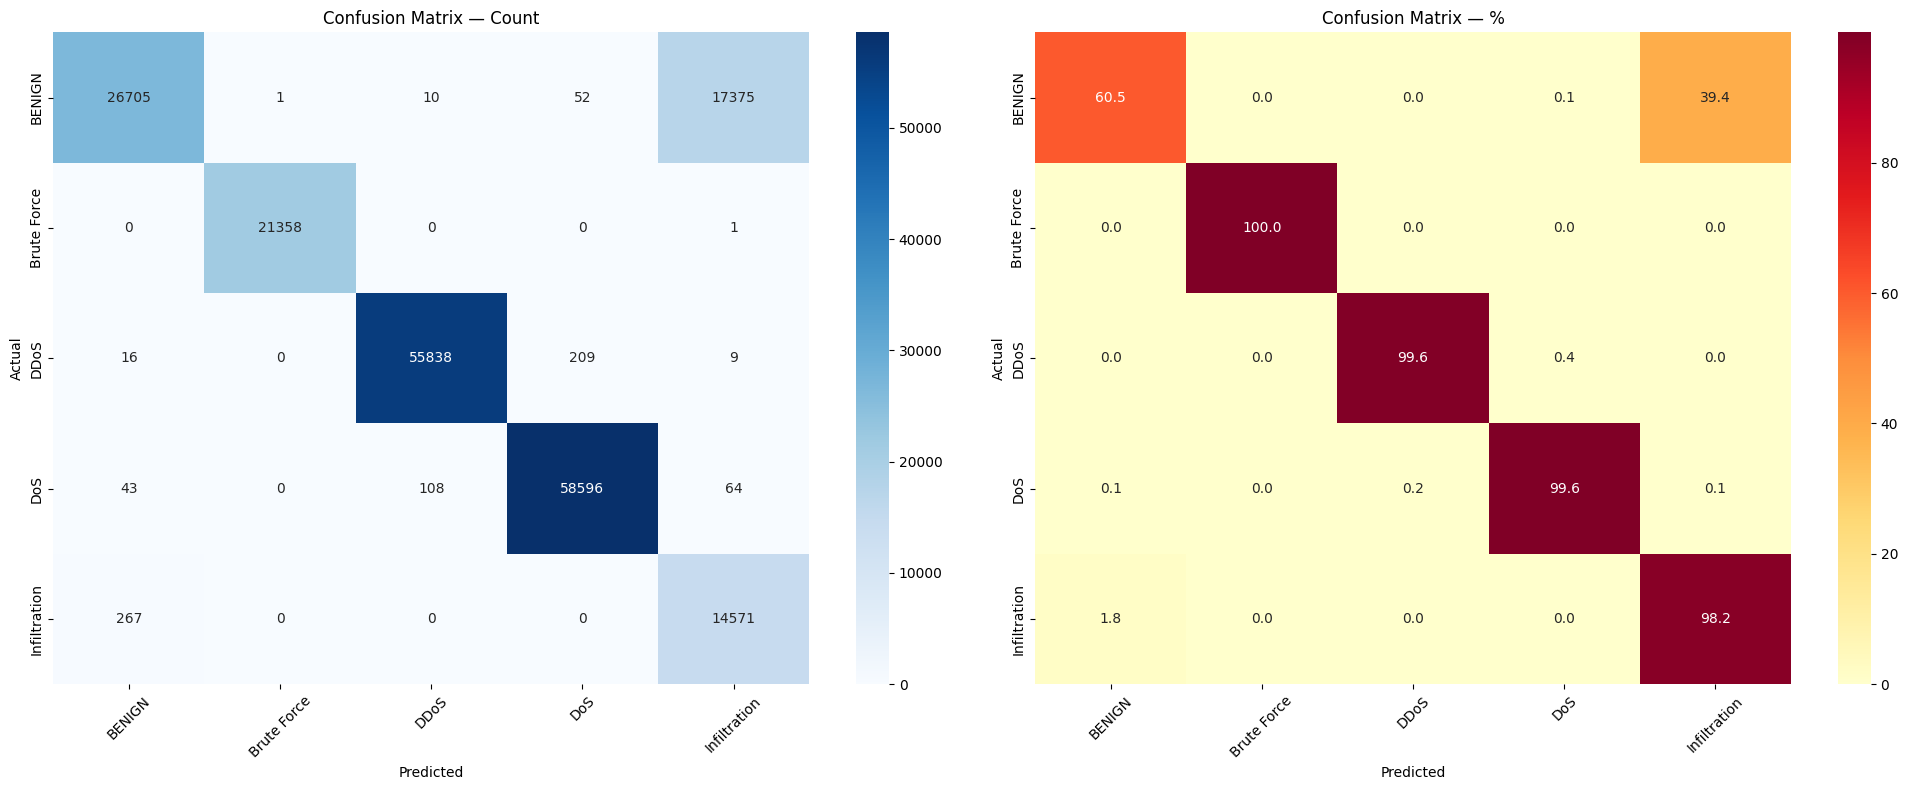

In [ ]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
